In [ ]:

#DATA HANDLING
import pandas as pd
import numpy as np

#DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

#DATA PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#MACHINE LEARNING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

#SUPPLIER RISK CLUSTERING
from sklearn.cluster import KMeans , DBSCAN

#MODEL CALIBRATION
from sklearn.calibration import (
    CalibratedClassifierCV ,
    calibration_curve
)

#EXPLAINABLE AI
import shap


#OPTIMIZATION
from scipy.optimize import linprog




In [ ]:
import pandas as pd

df = pd.read_csv("/content/Raw_Data.csv", low_memory=False)

# Rename first column
df.rename(columns={df.columns[0]: "ID"}, inplace=True)

# Convert date columns
date_columns = [
    "PQ First Sent to Client Date",
    "PO Sent to Vendor Date",
    "Scheduled Delivery Date",
    "Delivered to Client Date",
    "Delivery Recorded Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df.columns.tolist())

print("\nData types after date conversion:")
print(df[date_columns].dtypes)

# Convert numerical columns
numeric_columns = [
    "Weight (Kilograms)",
    "Freight Cost (USD)",
    "Line Item Insurance (USD)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ""),
        errors="coerce"
    )

print("\nNumerical column types:")
print(df[numeric_columns].dtypes)

print("\nMissing values in numerical columns:")
print(df[numeric_columns].isnull().sum())

# Check missing values in all columns

missing_values = df.isnull().sum()

print("\nMissing values in each column:")
print(missing_values[missing_values > 0])

# Handle missing values

# Categorical columns
df["Shipment Mode"] = df["Shipment Mode"].fillna("Unknown")
df["Dosage"] = df["Dosage"].fillna("Unknown")

# Numerical column
df["Line Item Insurance (USD)"] = df["Line Item Insurance (USD)"].fillna(0)

# Remove columns with almost no useful information
df.drop(columns=["Load_Date", "Source_System"], inplace=True)

print("\nMissing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Detailed inspection of remaining missing values

for col in df.columns:
    missing = df[col].isnull().sum()

    if missing > 0:
        percentage = (missing / len(df)) * 100
        print(f"{col}: {missing} missing ({percentage:}%)")

# Inspect missing values and related information

columns_to_check = [
    "PQ First Sent to Client Date",
    "PO Sent to Vendor Date",
    "Weight (Kilograms)",
    "Freight Cost (USD)"
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print("Missing:", df[col].isnull().sum())
    print("Non-missing:", df[col].notnull().sum())
    print("Data type:", df[col].dtype)
    print("Sample values:")
    print(df[col].dropna().head(10).tolist())

    # Create shipment delay

df["Delay_Days"] = (
    df["Delivered to Client Date"] - df["Scheduled Delivery Date"]
).dt.days

# Create binary target
df["Is_Delayed"] = (df["Delay_Days"] > 0).astype(int)

print("\nDelay statistics:")
print(df["Delay_Days"].describe())

print("\nDelayed vs On-time shipments:")
print(df["Is_Delayed"].value_counts())

# Create planned lead time

df["Planned_Lead_Time_Days"] = (
    df["Scheduled Delivery Date"] - df["PO Sent to Vendor Date"]
).dt.days

print("\nPlanned lead time statistics:")
print(df["Planned_Lead_Time_Days"].describe())
# Investigate invalid planned lead times

invalid_lead_time = df[df["Planned_Lead_Time_Days"] < 0]

print("\nNegative planned lead-time records:")
print(invalid_lead_time[
    [
        "ID",
        "PO Sent to Vendor Date",
        "Scheduled Delivery Date",
        "Planned_Lead_Time_Days"
    ]
].head(20))

print("\nNumber of negative lead times:")
print(len(invalid_lead_time))

# Check unusually large planned lead times

print("\nLead times greater than 365 days:")
print(
    (df["Planned_Lead_Time_Days"] > 365).sum()
)

df.loc[df["Planned_Lead_Time_Days"] < 0, "Planned_Lead_Time_Days"] = pd.NA

# Handle invalid planned lead times

df.loc[
    df["Planned_Lead_Time_Days"] < 0,
    "Planned_Lead_Time_Days"
] = pd.NA

print("\nNegative planned lead times after correction:")
print(
    (df["Planned_Lead_Time_Days"] < 0).sum()
)

# Check for duplicate records

print("\nDuplicate rows:")
print(df.duplicated().sum())
print("\nDuplicate shipment IDs:")
print(df["ID"].duplicated().sum())
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("\nCategorical columns:")
print(categorical_columns.tolist())
# Inspect unique values in categorical columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(20))

# Check categorical columns for inconsistencies

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique(dropna=False)}")

    print("\nUnique values:")
    print(df[col].dropna().unique())

    # Check spaces
    original = df[col].dropna().astype(str)
    stripped = original.str.strip()

    print(
        "\nValues with leading/trailing spaces:",
        (original != stripped).sum()
    )

    # Check case/spacing inconsistencies
    normalized = stripped.str.lower()

    if normalized.nunique() < original.nunique():
        print("Possible duplicate categories after normalization")
    else:
        print("No obvious case/spacing duplicates")

# Summary of categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nCategorical column summary:")

for col in categorical_columns:
    print(
        f"{col}: "
        f"{df[col].nunique(dropna=False)} unique values"
    )

# Remove pure identifier columns

identifier_columns = [
    "PQ #",
    "PO / SO #",
    "ASN/DN #"
]

df.drop(columns=identifier_columns, inplace=True)

print("\nRemoved identifier columns:")
print(identifier_columns)

# Clean categorical text values

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

print("\nCategorical text cleaned.")

# Numerical data summary

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("\nNumerical columns:")
print(numeric_columns.tolist())

print("\nNumerical summary:")
print(df[numeric_columns].describe().T)

# Check negative values in numerical columns

print("\nNegative value check:")

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()

    if negative_count > 0:
        print(f"{col}: {negative_count} negative values")

# Check zero values

print("\nZero value check:")

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()

    if zero_count > 0:
        print(f"{col}: {zero_count} zero values")

# Inspect suspicious zero values

zero_check_columns = [
    "Line Item Value",
    "Pack Price",
    "Unit Price",
    "Weight (Kilograms)",
    "Line Item Insurance (USD)"
]

for col in zero_check_columns:
    zero_rows = df[df[col] == 0]

    print(f"\n--- {col} ---")
    print(f"Zero values: {len(zero_rows)}")

    if len(zero_rows) > 0:
        print(
            zero_rows[
                [
                    "ID",
                    col,
                    "Product Group",
                    "Vendor"
                ]
            ].head(10)
        )
# Treat zero weight as missing because shipment weight should not be zero
df.loc[df["Weight (Kilograms)"] == 0, "Weight (Kilograms)"] = pd.NA
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(
    df[numerical_columns]
    .describe()
    .T
)
# Check potential outliers using the IQR method

numerical_columns = [
    "Line Item Value",
    "Pack Price",
    "Unit Price",
    "Weight (Kilograms)",
    "Freight Cost (USD)",
    "Line Item Insurance (USD)",
    "Planned_Lead_Time_Days"
]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n--- {col} ---")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Potential outliers: {len(outliers)}")
# Check skewness of numerical variables

for col in numerical_columns:
    skewness = df[col].skew()
    print(f"{col}: {skewness:.2f}")

/tmp/ipykernel_1320/183418396.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipykernel_1320/183418396.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipykernel_1320/183418396.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipykernel_1320/183418396.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent

['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'Load_Date', 'Source_System']

Data types after date conversion:
PQ First Sent to Client Date    datetime64[ns]
PO Sent to Vendor Date          datetime64[ns]
Scheduled Delivery Date         datetime64[ns]
Delivered to Client Date        datetime64[ns]
Delivery Recorded Date          datetime64[ns]
dtype: object

Numerical column types:
Weight (Kilograms)           float64
Freight

In [ ]:
#Model Creation

model_df = df.copy()

# Remove rows without a target label
model_df = model_df.dropna(subset=["Is_Delayed"])


# Convert target to integer
model_df["Is_Delayed"] = model_df["Is_Delayed"].astype(int)

# Removing Leakage

columns_to_drop = [
    "Is_Delayed",
    "Delay_Days",
    "Delivered to Client Date",
    "Delivery Recorded Date",
    "ID",
    "PQ #",
    "PO / SO #",
    "ASN/DN #"
]

# removing raw datetime columns for this first model

date_columns = model_df.select_dtypes(include = ["datetime","datetimetz"]).columns.tolist()

columns_to_drop = list(set(columns_to_drop + date_columns))


# Drop only columns that exist
columns_to_drop = [
    col for col in columns_to_drop if col in model_df.columns
]


X = model_df.drop(columns=columns_to_drop)
Y = model_df["Is_Delayed"]

print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(Y.value_counts())

print("\nTarget proportions:")
print(Y.value_counts(normalize=True))




Feature shape: (10324, 25)
Target shape: (10324,)

Features:
['Project Code', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'Planned_Lead_Time_Days']

Target distribution:
Is_Delayed
0    9138
1    1186
Name: count, dtype: int64

Target proportions:
Is_Delayed
0    0.885122
1    0.114878
Name: proportion, dtype: float64


In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X,
    Y,
    test_size = 0.20,
    random_state = 42,
    stratify = Y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8259, 25)
Testing data: (2065, 25)


In [ ]:
# Identify numerical columns

numeric_features = X_train.select_dtypes(include = ["number"]).columns.tolist()

# Identify categorical columns

categorical_features = X_train.select_dtypes(include = ["object", "string" , "category", "bool"]).columns.tolist()


# Numerical Pipeline

numeric_transformer = Pipeline(
    steps = [
        ("imputer" , SimpleImputer(strategy = "median")),
        ("scaler" , StandardScaler())
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)



Numerical features: ['Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'Planned_Lead_Time_Days']
Categorical features: ['Project Code', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Manufacturing Site', 'First Line Designation']


In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
rf_model.fit(X_train, Y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# Predict classes and probabilities
Y_pred = rf_model.predict(X_test)
Y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:",
      round(accuracy_score(Y_test, Y_pred), 4))

print("Precision:",
      round(precision_score(
          Y_test, Y_pred, zero_division=0
      ), 4))

print("Recall:",
      round(recall_score(
          Y_test, Y_pred, zero_division=0
      ), 4))

print("F1 Score:",
      round(f1_score(
          Y_test, Y_pred, zero_division=0
      ), 4))

print("ROC-AUC:",
      round(roc_auc_score(Y_test, Y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(
    Y_test, Y_pred, zero_division=0
))

Accuracy: 0.8266
Precision: 0.3476
Recall: 0.5823
F1 Score: 0.4353
ROC-AUC: 0.8562

Confusion Matrix:
[[1569  259]
 [  99  138]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1828
           1       0.35      0.58      0.44       237

    accuracy                           0.83      2065
   macro avg       0.64      0.72      0.67      2065
weighted avg       0.87      0.83      0.84      2065



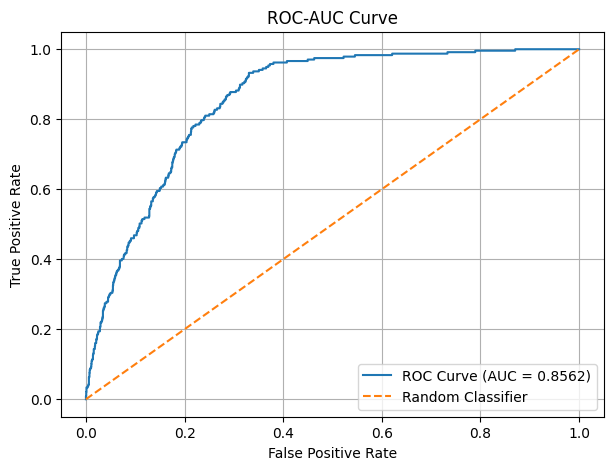

In [ ]:
# ROC - AUC Curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
roc_auc = roc_auc_score(Y_test, Y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr, tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid()
plt.show()



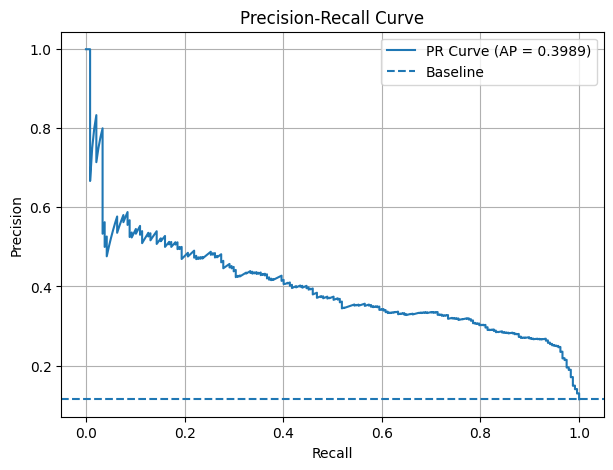

In [ ]:
# Precision-Recall Curve

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(Y_test, Y_prob)
)

avg_precision = average_precision_score(Y_test, Y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values, precision_values,
    label=f"PR Curve (AP = {avg_precision:.4f})"
)

plt.axhline(
    y=np.mean(Y_test),
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()


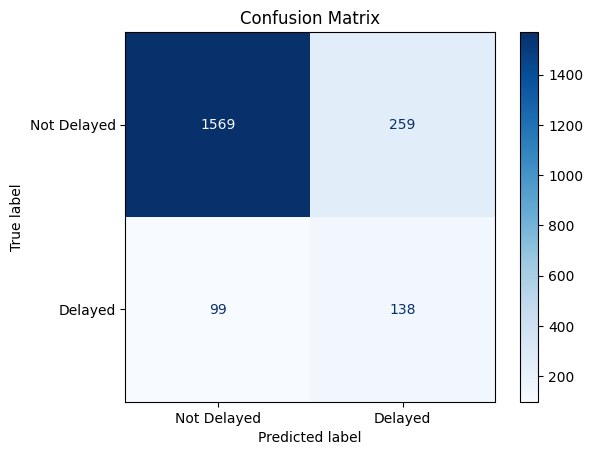

In [ ]:
# Confusion Matrix Plot

cm = confusion_matrix(Y_test, Y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
).plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")
plt.show()


Threshold Comparison:
   Threshold  Precision  Recall  F1 Score
0        0.2      0.231   0.966     0.372
1        0.3      0.266   0.920     0.412
2        0.4      0.306   0.793     0.442
3        0.5      0.348   0.582     0.435
4        0.6      0.432   0.363     0.394
5        0.7      0.514   0.160     0.244

Logistic Regression trained.

Model Comparison:
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.7182     0.2757  0.8945  0.4215   0.8468
1        Random Forest    0.8266     0.3476  0.5823  0.4353   0.8562

Top 20 Important Features:
                                  Feature  Importance
7          num__Line Item Insurance (USD)    0.058770
1                 num__Line Item Quantity    0.055046
2                    num__Line Item Value    0.051442
3                         num__Pack Price    0.050522
4                         num__Unit Price    0.041691
5                 num__Weight (Kilograms)    0.041002
6                 num

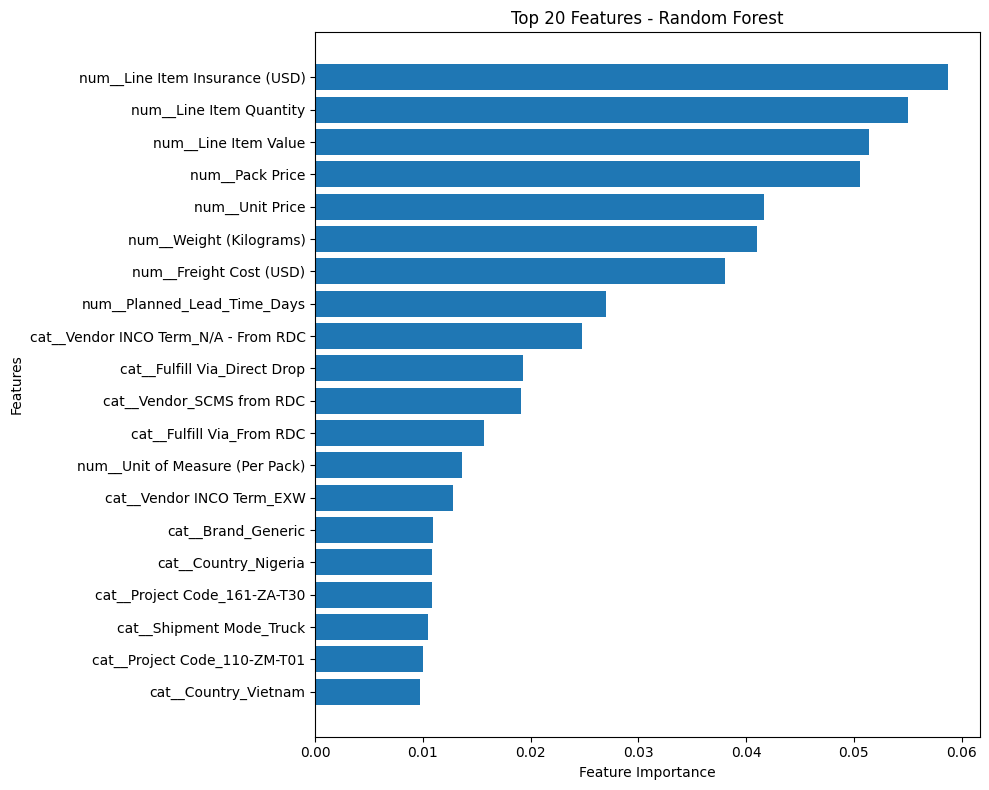

In [ ]:
#  THRESHOLD COMPARISON

threshold_results = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:

    Y_pred_threshold = (Y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_test, Y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            Y_test, Y_pred_threshold, zero_division=0
        ),
        "F1 Score": f1_score(
            Y_test, Y_pred_threshold, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("\nThreshold Comparison:")
print(threshold_df.round(3))


#  LOGISTIC REGRESSION BASELINE

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, Y_train)

print("\nLogistic Regression trained.")


#  COMPARE BOTH MODELS


models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model
}

comparison = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, pred),
        "Precision": precision_score(
            Y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            Y_test, pred, zero_division=0
        ),
        "F1": f1_score(
            Y_test, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(Y_test, prob)
    })

comparison_df = pd.DataFrame(comparison)

print("\nModel Comparison:")
print(comparison_df.round(4))



#  RANDOM FOREST FEATURE IMPORTANCE


feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model.named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features:")
print(importance_df.head(20))


# Plot top 20 features
top_features = importance_df.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Features - Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# HYPERPARAMETER TUNING

# Random Forest
rf_tune = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

# Pipeline
rf_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_tune)
])

# Smaller search space
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

random_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(random_search.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__class_weight': 'balanced_subsample'}

Best Cross-Validation ROC-AUC:
0.833


In [ ]:
# GET BEST MODEL


best_rf_model = random_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [ ]:

Y_pred_tuned = best_rf_model.predict(X_test)

Y_prob_tuned = (
    best_rf_model.predict_proba(X_test)[:, 1]
)

print("TUNED RANDOM FOREST")

print("\nAccuracy:",
      round(
          accuracy_score(Y_test, Y_pred_tuned),
          4
      ))

print("Precision:",
      round(
          precision_score(
              Y_test,
              Y_pred_tuned,
              zero_division=0
          ),
          4
      ))

print("Recall:",
      round(
          recall_score(
              Y_test,
              Y_pred_tuned,
              zero_division=0
          ),
          4
      ))

print("F1 Score:",
      round(
          f1_score(
              Y_test,
              Y_pred_tuned,
              zero_division=0
          ),
          4
      ))

print("ROC-AUC:",
      round(
          roc_auc_score(
              Y_test,
              Y_prob_tuned
          ),
          4
      ))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        Y_test,
        Y_pred_tuned
    )
)

print("\nClassification Report:")
print(
    classification_report(
        Y_test,
        Y_pred_tuned,
        zero_division=0
    )
)

TUNED RANDOM FOREST

Accuracy: 0.785
Precision: 0.3135
Recall: 0.7342
F1 Score: 0.4394
ROC-AUC: 0.8519

Confusion Matrix:
[[1447  381]
 [  63  174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      1828
           1       0.31      0.73      0.44       237

    accuracy                           0.78      2065
   macro avg       0.64      0.76      0.65      2065
weighted avg       0.88      0.78      0.82      2065



In [ ]:
# trying out XGBoost

from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)
Y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy_score(Y_test, Y_pred_xgb))
print("Precision:", precision_score(Y_test, Y_pred_xgb, zero_division=0))
print("Recall   :", recall_score(Y_test, Y_pred_xgb, zero_division=0))
print("F1 Score :", f1_score(Y_test, Y_pred_xgb, zero_division=0))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_xgb))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_xgb, zero_division=0))

XGBoost Results
----------------
Accuracy : 0.888135593220339
Precision: 0.5483870967741935
Recall   : 0.14345991561181434
F1 Score : 0.22742474916387959
ROC-AUC  : 0.8606198469194619

Confusion Matrix:
[[1800   28]
 [ 203   34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1828
           1       0.55      0.14      0.23       237

    accuracy                           0.89      2065
   macro avg       0.72      0.56      0.58      2065
weighted avg       0.86      0.89      0.86      2065



In [ ]:
threshold_results_xgb = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:

    Y_pred_threshold = (
        Y_prob_xgb >= threshold
    ).astype(int)

    threshold_results_xgb.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        )
    })

threshold_xgb_df = pd.DataFrame(
    threshold_results_xgb
)

print(
    threshold_xgb_df.round(3)
)

   Threshold  Precision  Recall  F1 Score
0        0.2      0.342   0.624     0.442
1        0.3      0.410   0.397     0.403
2        0.4      0.513   0.253     0.339
3        0.5      0.548   0.143     0.227
4        0.6      0.581   0.076     0.134
5        0.7      0.500   0.017     0.033


In [ ]:
# XGBoost Hyperparameter Tuning

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_tune = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=1
)

xgb_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_tune)
])

param_dist_xgb = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 10],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_alpha": [0, 0.01, 0.1, 1],
    "classifier__reg_lambda": [1, 1.5, 2, 5],
    "classifier__scale_pos_weight": [1, 2, 3, 5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tune_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, Y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Unit '
                                                                                'of '
                                                                                'Measure '
                                                                                '(Per '
                                                                                'Pack)',
                                                                                'Line '
                                                                                'Item '
                                                                                'Quantity',
                                                                                'Line '
                                                                                'Item '
                                                                                'Value',
                                                                                'Pack '
                                                                                'Price',
                                                                                'Unit '
                                                                                'Price',
                                                                                'Weight '
                                                                                '(Kilograms)',
                                                                                'Freight '
                                                                                'Cost '
                                                                                '(USD)',
                                                                                'Lin...
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 4, 5, 6,
                                                                  8],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5,
                                                                         10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__reg_alpha': [0, 0.01, 0.1,
                                                                  1],
                                        'classifier__reg_lambda': [1, 1.5, 2,
                                                                   5],
                                        'classifier__scale_pos_weight': [1, 2,
                                                                         3, 5],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scor

In [ ]:
print("Best XGBoost Parameters:")
print(random_search_xgb.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(
    round(
        random_search_xgb.best_score_,
        4
    )
)

Best XGBoost Parameters:
{'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 2, 'classifier__reg_lambda': 2, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.03, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 1.0}

Best Cross-Validation ROC-AUC:
0.8427


In [ ]:
# Best tuned XGBoost model

best_xgb_model = random_search_xgb.best_estimator_

Y_pred_xgb_tuned = best_xgb_model.predict(X_test)

Y_prob_xgb_tuned = (
    best_xgb_model.predict_proba(X_test)[:, 1]
)

print("TUNED XGBOOST")
print("----------------")

print("\nAccuracy:",
      round(
          accuracy_score(
              Y_test,
              Y_pred_xgb_tuned
          ),
          4
      ))

print("Precision:",
      round(
          precision_score(
              Y_test,
              Y_pred_xgb_tuned,
              zero_division=0
          ),
          4
      ))

print("Recall:",
      round(
          recall_score(
              Y_test,
              Y_pred_xgb_tuned,
              zero_division=0
          ),
          4
      ))

print("F1 Score:",
      round(
          f1_score(
              Y_test,
              Y_pred_xgb_tuned,
              zero_division=0
          ),
          4
      ))

print("ROC-AUC:",
      round(
          roc_auc_score(
              Y_test,
              Y_prob_xgb_tuned
          ),
          4
      ))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        Y_test,
        Y_pred_xgb_tuned
    )
)

print("\nClassification Report:")
print(
    classification_report(
        Y_test,
        Y_pred_xgb_tuned,
        zero_division=0
    )
)

TUNED XGBOOST
----------------

Accuracy: 0.8833
Precision: 0.4851
Recall: 0.2743
F1 Score: 0.3504
ROC-AUC: 0.861

Confusion Matrix:
[[1759   69]
 [ 172   65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1828
           1       0.49      0.27      0.35       237

    accuracy                           0.88      2065
   macro avg       0.70      0.62      0.64      2065
weighted avg       0.86      0.88      0.87      2065



In [ ]:
threshold_results_xgb_tuned = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:

    Y_pred_threshold = (
        Y_prob_xgb_tuned >= threshold
    ).astype(int)

    threshold_results_xgb_tuned.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            Y_test,
            Y_pred_threshold,
            zero_division=0
        )
    })

threshold_xgb_tuned_df = pd.DataFrame(
    threshold_results_xgb_tuned
)

print(
    threshold_xgb_tuned_df.round(3)
)

   Threshold  Precision  Recall  F1 Score
0        0.2      0.285   0.878     0.430
1        0.3      0.330   0.696     0.448
2        0.4      0.405   0.477     0.438
3        0.5      0.485   0.274     0.350
4        0.6      0.571   0.169     0.261
5        0.7      0.576   0.080     0.141


In [ ]:
# Final Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest",
        "XGBoost (Threshold 0.20)",
        "Tuned XGBoost (Threshold 0.30)"
    ],
    "Accuracy": [
        0.8266,
        0.7850,
        accuracy_score(
            Y_test,
            (Y_prob_xgb >= 0.20).astype(int)
        ),
        accuracy_score(
            Y_test,
            (Y_prob_xgb_tuned >= 0.30).astype(int)
        )
    ],
    "Precision": [
        0.3476,
        0.3135,
        precision_score(
            Y_test,
            (Y_prob_xgb >= 0.20).astype(int)
        ),
        precision_score(
            Y_test,
            (Y_prob_xgb_tuned >= 0.30).astype(int)
        )
    ],
    "Recall": [
        0.5823,
        0.7342,
        recall_score(
            Y_test,
            (Y_prob_xgb >= 0.20).astype(int)
        ),
        recall_score(
            Y_test,
            (Y_prob_xgb_tuned >= 0.30).astype(int)
        )
    ],
    "F1": [
        0.4353,
        0.4394,
        f1_score(
            Y_test,
            (Y_prob_xgb >= 0.20).astype(int)
        ),
        f1_score(
            Y_test,
            (Y_prob_xgb_tuned >= 0.30).astype(int)
        )
    ],
    "ROC-AUC": [
        0.8562,
        0.8519,
        roc_auc_score(Y_test, Y_prob_xgb),
        roc_auc_score(Y_test, Y_prob_xgb_tuned)
    ]
})

print(model_comparison.round(4))

                            Model  Accuracy  Precision  Recall      F1  \
0          Baseline Random Forest    0.8266     0.3476  0.5823  0.4353   
1             Tuned Random Forest    0.7850     0.3135  0.7342  0.4394   
2        XGBoost (Threshold 0.20)    0.8189     0.3418  0.6245  0.4418   
3  Tuned XGBoost (Threshold 0.30)    0.8029     0.3300  0.6962  0.4478   

   ROC-AUC  
0   0.8562  
1   0.8519  
2   0.8606  
3   0.8610  


In [ ]:

# SUPPLIER RISK ANALYTICS


supplier_df = df.copy()


#  Basic supplier shipment statistics


supplier_risk = supplier_df.groupby("Vendor").agg(
    Total_Shipments=("ID", "count"),

    Delayed_Shipments=("Is_Delayed", "sum"),

    Delay_Rate=("Is_Delayed", "mean"),

    Avg_Delay_Days=("Delay_Days", "mean"),

    Max_Delay_Days=("Delay_Days", "max"),

    Delay_Variability=("Delay_Days", "std"),

    Total_Freight_Cost=("Freight Cost (USD)", "sum"),

    Avg_Freight_Cost=("Freight Cost (USD)", "mean"),

    Total_Weight=("Weight (Kilograms)", "sum"),

    Avg_Weight=("Weight (Kilograms)", "mean")
).reset_index()


#  On-time shipment rate


supplier_risk["On_Time_Rate"] = (
    1 - supplier_risk["Delay_Rate"]
)



#  Average delay among delayed shipments


delayed_only = supplier_df[
    supplier_df["Is_Delayed"] == 1
]

avg_delay_delayed = (
    delayed_only
    .groupby("Vendor")["Delay_Days"]
    .mean()
    .rename("Avg_Delay_When_Delayed")
)

supplier_risk = supplier_risk.merge(
    avg_delay_delayed,
    on="Vendor",
    how="left"
)



#  Freight cost efficiency


supplier_risk["Freight_Cost_per_Kg"] = (
    supplier_risk["Total_Freight_Cost"]
    / supplier_risk["Total_Weight"].replace(0, np.nan)
)



#  Number of countries served


supplier_risk["Countries_Served"] = (
    supplier_df
    .groupby("Vendor")["Country"]
    .nunique()
    .values
)



#  Number of shipment modes used


supplier_risk["Shipment_Modes_Used"] = (
    supplier_df
    .groupby("Vendor")["Shipment Mode"]
    .nunique()
    .values
)



#  Main shipment mode dependence


mode_counts = (
    supplier_df
    .groupby(["Vendor", "Shipment Mode"])
    .size()
    .reset_index(name="Shipments")
)

vendor_totals = (
    mode_counts
    .groupby("Vendor")["Shipments"]
    .transform("sum")
)

mode_counts["Mode_Share"] = (
    mode_counts["Shipments"] / vendor_totals
)

max_mode_share = (
    mode_counts
    .groupby("Vendor")["Mode_Share"]
    .max()
    .rename("Max_Shipment_Mode_Share")
)

supplier_risk = supplier_risk.merge(
    max_mode_share,
    on="Vendor",
    how="left"
)



# Clean missing values


supplier_risk[
    "Avg_Delay_When_Delayed"
] = supplier_risk[
    "Avg_Delay_When_Delayed"
].fillna(0)

supplier_risk[
    "Delay_Variability"
] = supplier_risk[
    "Delay_Variability"
].fillna(0)

supplier_risk[
    "Freight_Cost_per_Kg"
] = supplier_risk[
    "Freight_Cost_per_Kg"
].replace(
    [np.inf, -np.inf],
    np.nan
)

supplier_risk[
    "Freight_Cost_per_Kg"
] = supplier_risk[
    "Freight_Cost_per_Kg"
].fillna(
    supplier_risk["Freight_Cost_per_Kg"].median()
)



#  Display supplier analytics


print("Supplier Risk Analytics")
print("-----------------------")

print(
    supplier_risk.head(10).round(3)
)

print(
    "\nNumber of Suppliers:",
    supplier_risk.shape[0]
)

Supplier Risk Analytics
-----------------------
                                              Vendor  Total_Shipments  \
0                  ABBOTT LABORATORIES (PUERTO RICO)                1   
1                              ABBOTT LOGISTICS B.V.                1   
2    ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)              347   
3  ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...                4   
4                                   ACCESS BIO, INC.                1   
5                             ACCOUN NIGERIA LIMITED                3   
6                                 ACOUNS NIGERIA LTD                1   
7                                 ACTION MEDEOR E.V.                1   
8                      AHN (PTY) LTD (AKA UCB (S.A.)                1   
9                                   AMSTELFARMA B.V.                7   

   Delayed_Shipments  Delay_Rate  Avg_Delay_Days  Max_Delay_Days  \
0                  0       0.000           0.000               0   
1           

In [ ]:

# SUPPLIER RISK SCORE



#  Convert supplier metrics to 0-1 risk scores


supplier_risk["Delay_Rate_Risk"] = (
    supplier_risk["Delay_Rate"]
    .rank(pct=True)
)

supplier_risk["Delay_Severity_Risk"] = (
    supplier_risk["Avg_Delay_When_Delayed"]
    .rank(pct=True)
)

supplier_risk["Delay_Variability_Risk"] = (
    supplier_risk["Delay_Variability"]
    .rank(pct=True)
)

supplier_risk["Mode_Concentration_Risk"] = (
    supplier_risk["Max_Shipment_Mode_Share"]
    .rank(pct=True)
)

supplier_risk["Freight_Cost_Risk"] = (
    supplier_risk["Freight_Cost_per_Kg"]
    .rank(pct=True)
)



#  Composite Supplier Risk Score


supplier_risk["Supplier_Risk_Score"] = (
      0.40 * supplier_risk["Delay_Rate_Risk"]
    + 0.25 * supplier_risk["Delay_Severity_Risk"]
    + 0.15 * supplier_risk["Delay_Variability_Risk"]
    + 0.10 * supplier_risk["Mode_Concentration_Risk"]
    + 0.10 * supplier_risk["Freight_Cost_Risk"]
)



# Convert score to 0-100


supplier_risk["Supplier_Risk_Score_100"] = (
    supplier_risk["Supplier_Risk_Score"] * 100
)



#  Create risk categories


supplier_risk["Risk_Category"] = pd.cut(
    supplier_risk["Supplier_Risk_Score_100"],
    bins=[-np.inf, 33, 66, np.inf],
    labels=["Low", "Medium", "High"]
)



# Sort suppliers by risk


supplier_risk = supplier_risk.sort_values(
    "Supplier_Risk_Score_100",
    ascending=False
)



#  Display top-risk suppliers


print("TOP SUPPLIER RISK PROFILES")
print("--------------------------")

print(
    supplier_risk[
        [
            "Vendor",
            "Total_Shipments",
            "Delay_Rate",
            "On_Time_Rate",
            "Avg_Delay_When_Delayed",
            "Delay_Variability",
            "Freight_Cost_per_Kg",
            "Max_Shipment_Mode_Share",
            "Supplier_Risk_Score_100",
            "Risk_Category"
        ]
    ]
    .head(15)
    .round(3)
)

TOP SUPPLIER RISK PROFILES
--------------------------
                                               Vendor  Total_Shipments  \
15                      BIO-RAD LABORATORIES (FRANCE)               28   
61      SHANGHAI KEHUA BIOENGINEERING CO.,LTD.  (KHB)               70   
10                                   ASPEN PHARMACARE               41   
50                                      Orgenics, Ltd              754   
49                          Orasure Technologies Inc.               56   
38                            JSI R&T INSTITUTE, INC.               38   
12                               Abbott GmbH & Co. KG               21   
64  SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...                9   
22                                      CIPLA LIMITED              175   
67                         Standard Diagnostics, Inc.               98   
13                           Aurobindo Pharma Limited              668   
21                   CHEMBIO DIAGNOSTIC SYSTEMS, INC.     

In [ ]:
print("\nRisk Category Distribution")
print("--------------------------")

print(
    supplier_risk["Risk_Category"]
    .value_counts()
)


Risk Category Distribution
--------------------------
Risk_Category
Medium    49
High      20
Low        4
Name: count, dtype: int64


In [ ]:
print("\nRisk Score Summary")
print("------------------")

print(
    supplier_risk["Supplier_Risk_Score_100"]
    .describe()
    .round(2)
)


Risk Score Summary
------------------
count    73.00
mean     50.68
std      17.59
min      29.55
25%      39.62
50%      42.23
75%      72.12
max      86.10
Name: Supplier_Risk_Score_100, dtype: float64
